In [7]:
# 
library(data.table)

In [31]:
# get files
files = list.files('../derived/knockouts/', full.names = TRUE, pattern = 'ko_prob')
print(head(files))
print(head(fread(files[1])))

[1] "../derived/knockouts//ukb_wes_200k_phased_eur_maf002_chr10_ko_prob.tsv.gz"
[2] "../derived/knockouts//ukb_wes_200k_phased_eur_maf002_chr11_ko_prob.tsv.gz"
[3] "../derived/knockouts//ukb_wes_200k_phased_eur_maf002_chr12_ko_prob.tsv.gz"
[4] "../derived/knockouts//ukb_wes_200k_phased_eur_maf002_chr13_ko_prob.tsv.gz"
[5] "../derived/knockouts//ukb_wes_200k_phased_eur_maf002_chr14_ko_prob.tsv.gz"
[6] "../derived/knockouts//ukb_wes_200k_phased_eur_maf002_chr15_ko_prob.tsv.gz"
              Gene       s eur dosage singletons pKO
1:                 3032058   1      1          1 0.5
2: ENSG00000012779 1002053   1      1          1 0.5
3: ENSG00000012779 1073740   1      2          0 1.0
4: ENSG00000012779 1130832   1      1          1 0.5
5: ENSG00000012779 1191502   1      0          2 0.5
6: ENSG00000012779 1224135   1      1          1 0.5


In [35]:

samples <- unique(unlist(lapply(files, function(f){
    d = fread(f)
    return(d[d$pKO==1,]$s)
})))


In [36]:
length(samples)

[1] 98206

In [37]:
table(d$consequence_category)


damaging_missense        non_coding    other_missense               ptv 
           197025           4053103           2695038             68198 
       synonymous 
          1619851 

In [18]:
head(d)

Gene,consequence_category,s,eur,n,singletons,total
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>
ENSG00000003249,damaging_missense,2449449,1,1,0,1
ENSG00000003249,damaging_missense,2984703,1,1,0,1
ENSG00000003249,damaging_missense,4875086,1,0,1,1
ENSG00000003249,damaging_missense,4963725,1,1,0,1
ENSG00000003249,damaging_missense,5964568,1,0,1,1
ENSG00000003249,non_coding,1000171,1,1,0,1


In [19]:
x = as.data.table(table(d$s, d$consequence_category))

V1,V2,N
<chr>,<chr>,<int>
1000028,damaging_missense,1
1000034,damaging_missense,1
1000087,damaging_missense,3
1000118,damaging_missense,1
1000120,damaging_missense,1
1000162,damaging_missense,1


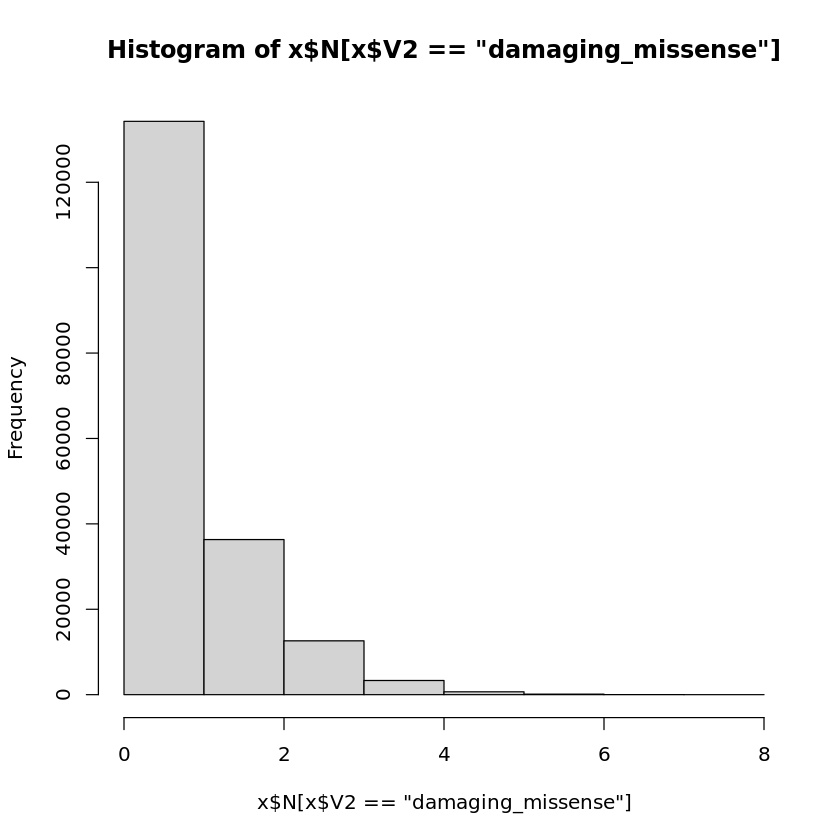

In [28]:
hist(x$N[x$V2=='damaging_missense'], breaks = 10)